In [41]:
# Import

# normal packeges
import os
import pandas as pd
import numpy as np

# visuals
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report

# Optional: filter warnings
import warnings
warnings.filterwarnings("ignore")

In [42]:
# Data load
data_path = "05_Data_Sets/"

# Data-Sets
job_salary = pd.read_csv(f"{data_path}job_salary_prediction_dataset.csv") 
university_ranking = pd.read_csv(f"{data_path}world_university_rankings_2026.csv") 
spotify_behavior = pd.read_csv(f"{data_path}spotify_user_behavior_realistic_50000_rows.csv")

# Show first rows 
print("Job Salary Prediction:")
display(job_salary.head()) 
print("\nUniversity Ranking:")
display(university_ranking.head()) 
print("\nSpotify Behavior:")
display(spotify_behavior.head())

Job Salary Prediction:


,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069



University Ranking:


,university,country,region,university_type,qs_rank_2026,the_rank_2026,arwu_rank_2025,qs_score,the_score,arwu_score,...,the_intl_outlook,founded,total_students,intl_students_pct,nobel_laureates,fields_medalists,ranked_in_all_3,avg_rank_all3,university_age_2026,data_sources
0,MIT,USA,North America,Private,1.0,2.0,3.0,100.0,96.4,100.0,...,74.2,1861,11858,34,100,1,True,2.0,165,QS Jun-2025 | THE Oct-2025 | ARWU Aug-2025
1,Imperial College London,UK,Europe,Public,2.0,8.0,NaN,99.2,86.1,NaN,...,55.2,1907,19000,61,15,0,False,5.0,119,QS Jun-2025 | THE Oct-2025 | ARWU Aug-2025
2,Stanford University,USA,North America,Private,3.0,5.0,2.0,99.1,95.5,76.5,...,88.4,1885,17249,24,85,22,True,3.3,141,QS Jun-2025 | THE Oct-2025 | ARWU Aug-2025
3,University of Oxford,UK,Europe,Public,4.0,1.0,6.0,98.9,97.0,72.4,...,66.4,1096,24000,41,72,0,True,3.7,930,QS Jun-2025 | THE Oct-2025 | ARWU Aug-2025
4,Harvard University,USA,North America,Private,5.0,5.0,1.0,98.8,95.5,100.0,...,77.4,1636,21000,25,162,4,True,3.7,390,QS Jun-2025 | THE Oct-2025 | ARWU Aug-2025



Spotify Behavior:


,user_id,country,age,signup_date,subscription_type,subscription_status,months_inactive,inactive_3_months_flag,ad_interaction,ad_conversion_to_subscription,music_suggestion_rating_1_to_5,avg_listening_hours_per_week,favorite_genre,most_liked_feature,desired_future_feature,primary_device,playlists_created,avg_skips_per_day
0,1,France,25,2021-08-19,Premium Duo,Active,0,0,No,No,4,10.13,Bollywood,Radio,Concert Alerts,Tablet,7,8
1,2,Indonesia,20,2022-06-06,Premium Family,Active,0,0,Yes,No,5,11.63,Latin,Podcasts,Lyrics Translation,Mobile,7,6
2,3,Italy,53,2024-01-04,Premium Individual,Active,0,0,Yes,Yes,3,9.50,Bollywood,Lyrics,Better AI Recommendations,Desktop,6,5
3,4,Italy,48,2018-08-26,Premium Individual,Active,1,0,No,No,4,13.16,Electronic,Playlists,Social Listening,Smart Speaker,11,8
4,5,Australia,18,2020-05-29,Free,Active,0,0,No,No,4,12.70,Indie,Daily Mix,Lyrics Translation,Tablet,10,11


In [43]:
# Data load
data_path = "05_Data_Sets/"

# Data-Sets
job_salary = pd.read_csv(f"{data_path}job_salary_prediction_dataset.csv")
university_ranking = pd.read_csv(f"{data_path}world_university_rankings_2026.csv")
spotify_behavior = pd.read_csv(f"{data_path}spotify_user_behavior_realistic_50000_rows.csv")

# Show first rows
print("Job Salary Prediction:")
display(job_salary.head())

print("\nUniversity Ranking:")
display(university_ranking.head())

print("\nSpotify Behavior:")
display(spotify_behavior.head())

Job Salary Prediction:


,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069



University Ranking:


,university,country,region,university_type,qs_rank_2026,the_rank_2026,arwu_rank_2025,qs_score,the_score,arwu_score,...,the_intl_outlook,founded,total_students,intl_students_pct,nobel_laureates,fields_medalists,ranked_in_all_3,avg_rank_all3,university_age_2026,data_sources
0,MIT,USA,North America,Private,1.0,2.0,3.0,100.0,96.4,100.0,...,74.2,1861,11858,34,100,1,True,2.0,165,QS Jun-2025 | THE Oct-2025 | ARWU Aug-2025
1,Imperial College London,UK,Europe,Public,2.0,8.0,NaN,99.2,86.1,NaN,...,55.2,1907,19000,61,15,0,False,5.0,119,QS Jun-2025 | THE Oct-2025 | ARWU Aug-2025
2,Stanford University,USA,North America,Private,3.0,5.0,2.0,99.1,95.5,76.5,...,88.4,1885,17249,24,85,22,True,3.3,141,QS Jun-2025 | THE Oct-2025 | ARWU Aug-2025
3,University of Oxford,UK,Europe,Public,4.0,1.0,6.0,98.9,97.0,72.4,...,66.4,1096,24000,41,72,0,True,3.7,930,QS Jun-2025 | THE Oct-2025 | ARWU Aug-2025
4,Harvard University,USA,North America,Private,5.0,5.0,1.0,98.8,95.5,100.0,...,77.4,1636,21000,25,162,4,True,3.7,390,QS Jun-2025 | THE Oct-2025 | ARWU Aug-2025



Spotify Behavior:


,user_id,country,age,signup_date,subscription_type,subscription_status,months_inactive,inactive_3_months_flag,ad_interaction,ad_conversion_to_subscription,music_suggestion_rating_1_to_5,avg_listening_hours_per_week,favorite_genre,most_liked_feature,desired_future_feature,primary_device,playlists_created,avg_skips_per_day
0,1,France,25,2021-08-19,Premium Duo,Active,0,0,No,No,4,10.13,Bollywood,Radio,Concert Alerts,Tablet,7,8
1,2,Indonesia,20,2022-06-06,Premium Family,Active,0,0,Yes,No,5,11.63,Latin,Podcasts,Lyrics Translation,Mobile,7,6
2,3,Italy,53,2024-01-04,Premium Individual,Active,0,0,Yes,Yes,3,9.50,Bollywood,Lyrics,Better AI Recommendations,Desktop,6,5
3,4,Italy,48,2018-08-26,Premium Individual,Active,1,0,No,No,4,13.16,Electronic,Playlists,Social Listening,Smart Speaker,11,8
4,5,Australia,18,2020-05-29,Free,Active,0,0,No,No,4,12.70,Indie,Daily Mix,Lyrics Translation,Tablet,10,11


In [44]:
# Ordner für Plots vorbereiten
plot_folder = "05_Outputs/plots"
os.makedirs(plot_folder, exist_ok=True)

# Alle offenen Figuren speichern
for i, fig_num in enumerate(plt.get_fignums(), start=1):
    fig = plt.figure(fig_num)
    filename = f"{plot_folder}/plot_{i}.png"  # automatische Nummerierung
    fig.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"Saved plot {i} -> {filename}")

In [45]:
# Create copies of data
df_jobsalaray_orig = pd.read_csv(f"{data_path}job_salary_prediction_dataset.csv")
df_universityranking_orig = pd.read_csv(f"{data_path}world_university_rankings_2026.csv")
df_spotifybehavior_orig = pd.read_csv(f"{data_path}spotify_user_behavior_realistic_50000_rows.csv")

# create Workcopy
df_jobsalaray = df_jobsalaray_orig.copy()
df_universityranking = df_universityranking_orig.copy()
df_spotifybehavior = df_spotifybehavior_orig.copy()

# quick Check
print("Job Salary:", df_jobsalaray.shape)
print("University Ranking:", df_universityranking.shape)
print("Spotify Behavior:", df_spotifybehavior.shape)

Job Salary: (250000, 10)
University Ranking: (57, 30)
Spotify Behavior: (50000, 18)


In [46]:
# missing values
print("Job Salary dataset missing values:\n", df_jobsalaray.isna().sum())
print("\nUniversity Ranking dataset missing values:\n", df_universityranking.isna().sum())
print("\nSpotify Behavior dataset missing values:\n", df_spotifybehavior.isna().sum())

Job Salary dataset missing values:
 job_title           0
experience_years    0
education_level     0
skills_count        0
industry            0
company_size        0
location            0
remote_work         0
certifications      0
salary              0
dtype: int64

University Ranking dataset missing values:
 university               0
country                  0
region                   0
university_type          0
qs_rank_2026             1
the_rank_2026            2
arwu_rank_2025          38
qs_score                 1
the_score                2
arwu_score              38
qs_academic_rep          1
qs_employer_rep          1
qs_faculty_student       1
qs_citations             1
qs_intl_faculty          1
qs_intl_students         1
the_teaching             2
the_research_env         2
the_research_quality     2
the_industry             2
the_intl_outlook         2
founded                  0
total_students           0
intl_students_pct        0
nobel_laureates          0
fields_meda

In [47]:
# Overview Statistics
print("Job Salary Stats:")
display(df_jobsalaray.describe())

print("\nUniversity Ranking Stats:")
display(df_universityranking.describe())

print("\nSpotify Behavior Stats:")
display(df_spotifybehavior.describe())

Job Salary Stats:


,experience_years,skills_count,certifications,salary
count,250000.000000,250000.000000,250000.000000,250000.000000
mean,10.005408,9.997812,2.491928,145718.080524
std,6.060602,5.479288,1.706475,37407.952729
min,0.000000,1.000000,0.000000,31867.000000
25%,5.000000,5.000000,1.000000,119358.000000
50%,10.000000,10.000000,2.000000,143453.000000
75%,15.000000,15.000000,4.000000,169492.000000
max,20.000000,19.000000,5.000000,333046.000000



University Ranking Stats:


,qs_rank_2026,the_rank_2026,arwu_rank_2025,qs_score,the_score,arwu_score,qs_academic_rep,qs_employer_rep,qs_faculty_student,qs_citations,...,the_research_quality,the_industry,the_intl_outlook,founded,total_students,intl_students_pct,nobel_laureates,fields_medalists,avg_rank_all3,university_age_2026
count,56.000000,55.000000,19.000000,56.000000,55.000000,19.000000,56.000000,56.000000,56.000000,56.000000,...,55.000000,55.000000,55.000000,57.000000,57.000000,57.000000,57.000000,57.000000,57.000000,57.000000
mean,45.964286,48.909091,18.421053,90.807143,77.190909,65.089474,93.342857,94.532143,94.439286,92.282143,...,73.716364,65.905455,69.650909,1833.473684,34930.543860,30.929825,26.105263,0.877193,51.254386,192.526316
std,74.918857,66.851209,20.059123,6.699494,11.782053,17.412476,5.815054,6.348002,6.369863,6.034179,...,18.778384,10.978488,12.308156,165.704999,21060.357052,16.497683,36.957835,3.088401,78.541629,165.704999
min,1.000000,1.000000,1.000000,62.400000,46.400000,33.400000,64.400000,62.800000,63.400000,64.400000,...,32.400000,34.400000,40.400000,1096.000000,2240.000000,3.000000,0.000000,0.000000,2.000000,11.000000
25%,13.000000,13.500000,5.500000,88.300000,70.600000,54.800000,92.150000,93.700000,93.250000,90.700000,...,59.900000,61.400000,61.300000,1826.000000,21000.000000,17.000000,1.000000,0.000000,13.500000,115.000000
50%,28.000000,27.000000,10.000000,91.200000,79.400000,64.200000,94.300000,96.500000,96.400000,93.000000,...,80.200000,68.400000,68.800000,1868.000000,29000.000000,30.000000,12.000000,0.000000,29.000000,158.000000
75%,43.250000,49.000000,23.000000,95.250000,84.900000,73.800000,96.800000,98.400000,97.500000,95.900000,...,87.300000,72.400000,74.300000,1911.000000,47000.000000,41.000000,26.000000,0.000000,46.500000,200.000000
max,488.000000,351.000000,81.000000,100.000000,97.000000,100.000000,100.000000,100.000000,100.000000,100.000000,...,99.400000,80.400000,100.000000,2015.000000,97000.000000,80.000000,162.000000,22.000000,488.000000,930.000000



Spotify Behavior Stats:


,user_id,age,months_inactive,inactive_3_months_flag,music_suggestion_rating_1_to_5,avg_listening_hours_per_week,playlists_created,avg_skips_per_day
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,25000.500000,38.010280,1.533020,0.222460,3.644100,9.988986,8.002680,10.025920
std,14433.901067,12.984989,1.952082,0.415903,1.114424,3.968927,2.831571,3.165579
min,1.000000,16.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000
25%,12500.750000,27.000000,0.000000,0.000000,3.000000,7.280000,6.000000,8.000000
50%,25000.500000,38.000000,1.000000,0.000000,4.000000,9.980000,8.000000,10.000000
75%,37500.250000,49.000000,2.000000,0.000000,5.000000,12.680000,10.000000,12.000000
max,50000.000000,60.000000,18.000000,1.000000,5.000000,26.250000,23.000000,25.000000


In [48]:
print(df_jobsalaray.dtypes)
print(df_universityranking.dtypes)
print(df_spotifybehavior.dtypes)

job_title           object
experience_years     int64
education_level     object
skills_count         int64
industry            object
company_size        object
location            object
remote_work         object
certifications       int64
salary               int64
dtype: object
university               object
country                  object
region                   object
university_type          object
qs_rank_2026            float64
the_rank_2026           float64
arwu_rank_2025          float64
qs_score                float64
the_score               float64
arwu_score              float64
qs_academic_rep         float64
qs_employer_rep         float64
qs_faculty_student      float64
qs_citations            float64
qs_intl_faculty         float64
qs_intl_students        float64
the_teaching            float64
the_research_env        float64
the_research_quality    float64
the_industry            float64
the_intl_outlook        float64
founded                   int64
total_studen

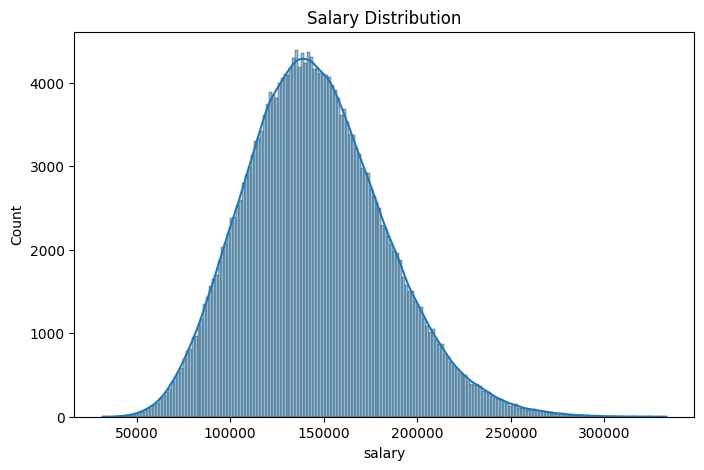

In [49]:
plt.figure(figsize=(8,5))
sns.histplot(df_jobsalaray['salary'], kde=True)
plt.title("Salary Distribution")
plt.show()

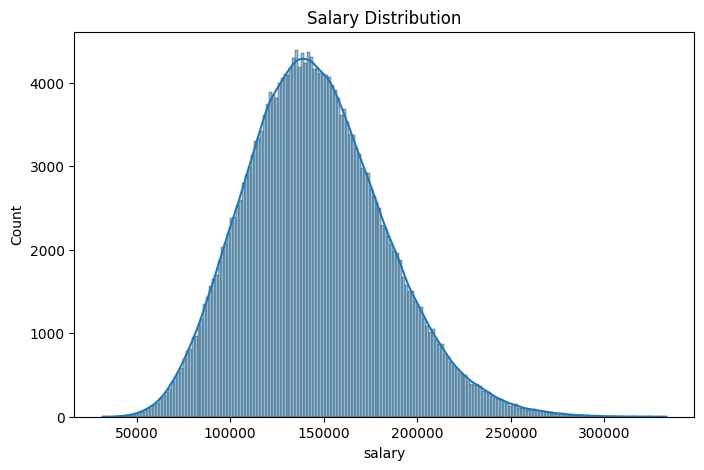

In [50]:
plt.figure(figsize=(8,5))
sns.histplot(df_jobsalaray['salary'], kde=True)
plt.title("Salary Distribution")
plt.show()

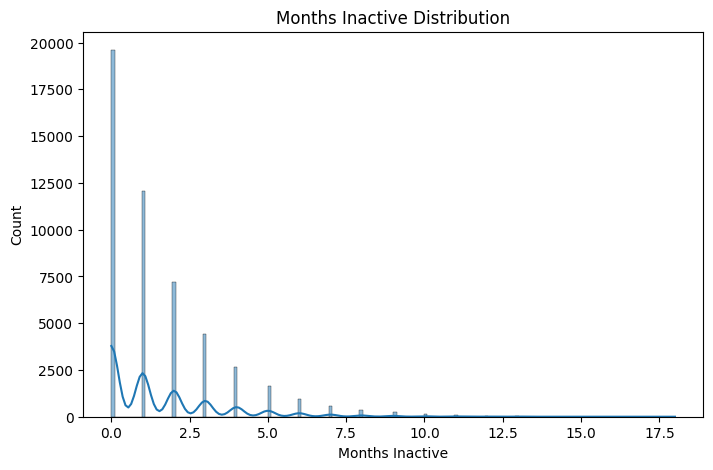

In [51]:
plt.figure(figsize=(8,5))
sns.histplot(df_spotifybehavior['months_inactive'], kde=True)
plt.title("Months Inactive Distribution")
plt.xlabel("Months Inactive")
plt.show()

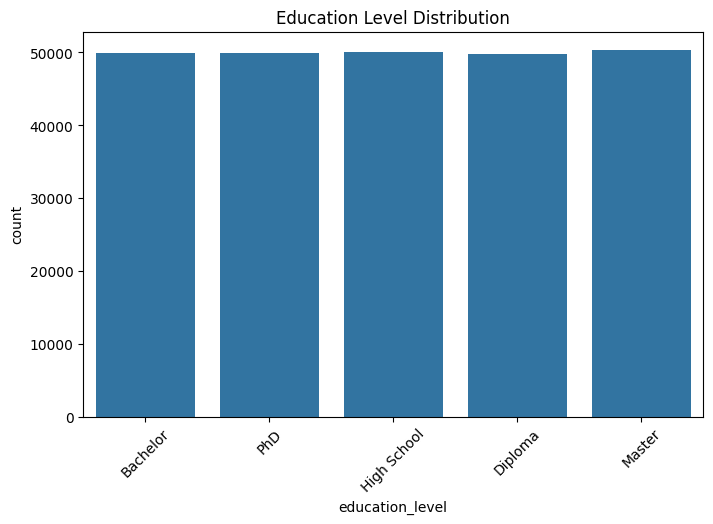

In [52]:
plt.figure(figsize=(8,5))
sns.countplot(data=df_jobsalaray, x='education_level')
plt.title("Education Level Distribution")
plt.xticks(rotation=45)
plt.show()

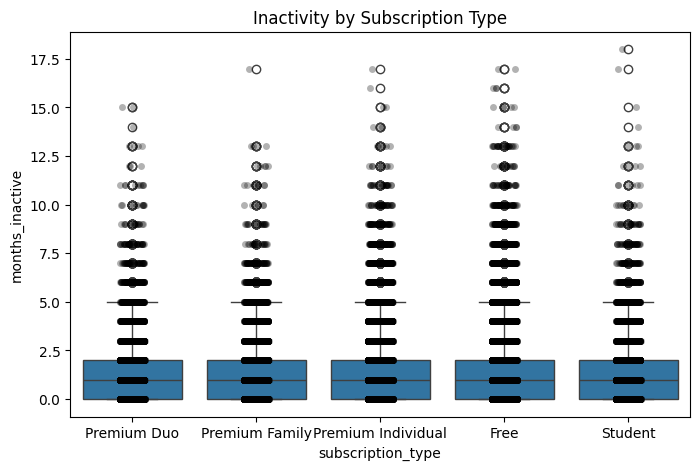

In [53]:
plt.figure(figsize=(8,5))
sns.boxplot(
    data=df_spotifybehavior, 
    x='subscription_type', 
    y='months_inactive'
)

sns.stripplot(
    data=df_spotifybehavior, 
    x='subscription_type', 
    y='months_inactive',
    color='black',
    alpha=0.3
)

plt.title("Inactivity by Subscription Type")
plt.show()

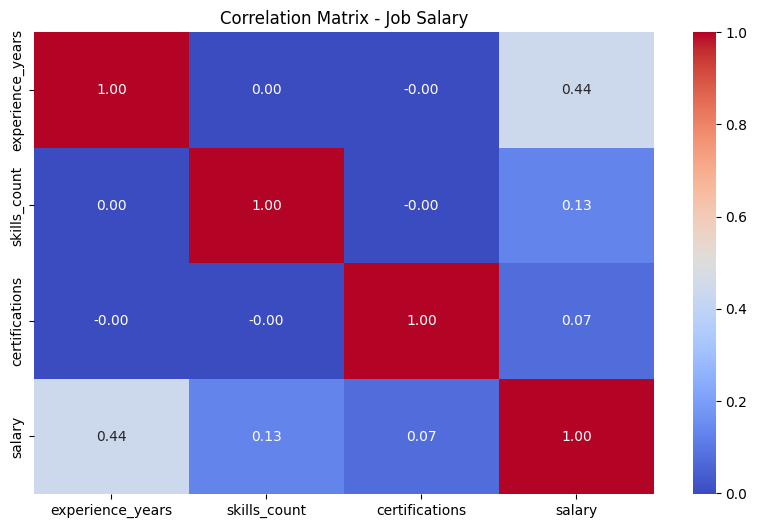

In [54]:
corr = df_jobsalaray.corr(numeric_only=True)

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix - Job Salary")
plt.show()

In [55]:
corr_target = df_jobsalaray.corr(numeric_only=True)['salary'].sort_values(ascending=False)

print(corr_target)

salary              1.000000
experience_years    0.437627
skills_count        0.127300
certifications      0.073819
Name: salary, dtype: float64


In [56]:
# Nur numerische Features verwenden
df_ml = df_jobsalaray.select_dtypes(include=[np.number])

# Zielvariable
target = 'salary'

# Features
X = df_ml.drop(columns=[target])
y = df_ml[target]

print("Features used:", X.columns)

Features used: Index(['experience_years', 'skills_count', 'certifications'], dtype='object')


In [57]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (200000, 3)
Test size: (50000, 3)


In [58]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(random_state=42)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

r2_rf = r2_score(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print("Random Forest -> R²:", round(r2_rf, 3))
print("Random Forest -> RMSE:", round(rmse_rf, 2))

Random Forest -> R²: 0.201
Random Forest -> RMSE: 33325.43


In [59]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(random_state=42)

gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)

r2_gb = r2_score(y_test, y_pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))

print("Gradient Boosting -> R²:", round(r2_gb, 3))
print("Gradient Boosting -> RMSE:", round(rmse_gb, 2))

Gradient Boosting -> R²: 0.209
Gradient Boosting -> RMSE: 33146.96


In [60]:
print("\nModel Comparison:")
print(f"Random Forest     -> R²: {r2_rf:.3f}, RMSE: {rmse_rf:.2f}")
print(f"Gradient Boosting -> R²: {r2_gb:.3f}, RMSE: {rmse_gb:.2f}")


Model Comparison:
Random Forest     -> R²: 0.201, RMSE: 33325.43
Gradient Boosting -> R²: 0.209, RMSE: 33146.96


In [61]:
import pandas as pd

feature_importance = pd.Series(rf_model.feature_importances_, index=X.columns)
feature_importance = feature_importance.sort_values(ascending=False)

print(feature_importance)

experience_years    0.840546
skills_count        0.110262
certifications      0.049193
dtype: float64


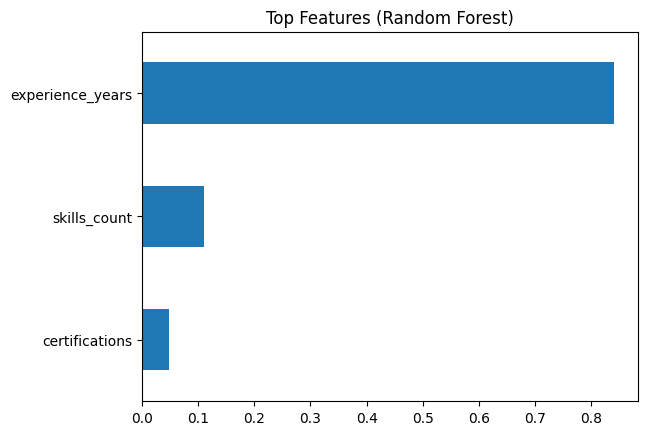

In [62]:
feature_importance.head(10).plot(kind='barh')
plt.title("Top Features (Random Forest)")
plt.gca().invert_yaxis()
plt.show()